## Embedding-based Classification Models with FNN and Logistic Regression

### This notebook builds embedding-based classification models using a Feedforward Neural Network (FNN) and Logistic Regression to compare performance on the given dataset.

In [1]:
import os
import time
import math
import numpy as np
import pandas as pd
import pyarrow
import torch
import torch.nn as nn
import random
import matplotlib.pyplot as plt


from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer
from sklearn.linear_model import LogisticRegression

In [2]:
def stratified_group_shuffle_split(X, y, groups, test_size=0.15, random_state=10):
    """
    Equivalent to StratifiedGroupShuffleSplit(n_splits=1, ...).
    Assumes each group has a single label (your case).
    Returns: train_idx, val_idx (row indices)
    """
    groups = np.asarray(groups)
    y = np.asarray(y)

    # 1) collapse row-level to group-level
    uniq_groups, first_idx = np.unique(groups, return_index=True)
    y_group = y[first_idx]  # label per group (in your data, label is constant within group)

    # 2) split on groups with stratification by group label
    sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    gtr, gva = next(sss.split(uniq_groups, y_group))
    train_groups = set(uniq_groups[gtr])
    val_groups   = set(uniq_groups[gva])

    # 3) map back to row indices
    train_idx = np.where(np.isin(groups, list(train_groups)))[0]
    val_idx   = np.where(np.isin(groups, list(val_groups)))[0]
    return train_idx, val_idx


In [3]:
DATA_PATH = r"E:\CV\Internship\Coding_Challenge_Omkar_Pawar\data\cleaned_sentiment_dataset.csv"  
EMB_PATH  = r"E:\CV\Internship\Coding_Challenge_Omkar_Pawar\notebooks\embeddings_out\miniLM_L6v2_embeddings_float16_new.mmap"

EMB_DIM   = 384          # all-MiniLM-L6-v2
EMB_DTYPE = np.float16

In [4]:
 main_df = pd.read_csv(DATA_PATH)

In [5]:
df = main_df.copy()
df

,id,product,sentiment,text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
...,...,...,...,...
70422,7516,LeagueOfLegends,Neutral,♥️ Suikoden 2\r\n1️⃣ Alex Kidd in Miracle Worl...
70423,5708,HomeDepot,Positive,Thank you to Matching funds Home Depot RW paym...
70424,2165,CallOfDuty,Neutral,Late night stream with the boys! Come watch so...
70425,4891,GrandTheftAuto(GTA),Irrelevant,⭐️ Toronto is the arts and culture capital of ...


### Load embeddings and verify shape

In [6]:
n_rows = len(df)

emb = np.memmap(EMB_PATH, dtype=EMB_DTYPE, mode="r", shape=(n_rows, EMB_DIM))
print("Embeddings shape:", emb.shape)
assert emb.shape == (n_rows, EMB_DIM), "Embeddings count doesn't match DataFrame rows!"

Embeddings shape: (70427, 384)


In [7]:
df_join = df.copy()
df_join["embedding"] = [row.astype(np.float32).tolist() for row in emb]  # cast to float32 for stability
df_join.head(2)

,id,product,sentiment,text,embedding
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,"[0.036834716796875, -0.0005779266357421875, -0..."
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,"[0.0587158203125, 0.0306854248046875, 0.001379..."


### Prepare features and labels

In [8]:
 # Ensure embeddings are numpy arrays and stack to a 2D array
X = np.vstack(df_join['embedding'].apply(lambda v: np.array(v, dtype=np.float32)).values)

In [9]:
label_map = {'Positive':0, 'Neutral':1, 'Irrelevant':2, 'Negative':3}
inv_label_map = {v:k for k,v in label_map.items()}
y = df_join['sentiment'].map(label_map).values
groups_row = df_join['id'].values  # row-level group labels

### Build a group-stratified split by id (no leakage)

In [10]:
# We stratify at the group level using the group's single sentiment label
group_df = (df_join[['id','sentiment']]
            .drop_duplicates(subset=['id'])
            .assign(y_group=lambda d: d['sentiment'].map(label_map)))

group_ids = group_df['id'].values
y_groups = group_df['y_group'].values

rng = 10
skf_groups = StratifiedKFold(n_splits=5, shuffle=True, random_state=rng)
# Take the FIRST split as a clean holdout; the loop below also runs CV
first_split = next(skf_groups.split(group_ids, y_groups))
train_group_idx, test_group_idx = first_split
train_group_ids = set(group_ids[train_group_idx])
test_group_ids  = set(group_ids[test_group_idx])

train_mask = np.array([gid in train_group_ids for gid in groups_row])
test_mask  = np.array([gid in test_group_ids  for gid in groups_row])

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

ids_train = groups_row[train_mask]  # 1D array, same length/order as X_train / y_train
ids_test  = groups_row[test_mask]   

print(f"Train rows: {X_train.shape[0]} | Test rows: {X_test.shape[0]}")
print("Leakage check (any id in both train & test?):",
      bool(set(groups_row[train_mask]).intersection(set(groups_row[test_mask]))))

Train rows: 56344 | Test rows: 14083
Leakage check (any id in both train & test?): False


### Model: Embeddings + FNN

In [11]:
# ----- Repro -----
SEED = 10
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ----- Data -----
num_classes = 4
input_dim = X_train.shape[1]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# stratified val split from TRAIN ( group-wise TEST is untouched)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
#tr_idx, va_idx = next(sss.split(X_train, y_train))
# group labels are ids, stratify by sentiment (y_train)
# ids_train must be a 1D array of the group id per row (aligned with X_train/y_train)
tr_idx, va_idx = stratified_group_shuffle_split(X_train, y_train, groups=ids_train, 
                                                test_size=0.15, random_state=SEED)
X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
X_va, y_va = X_train[va_idx], y_train[va_idx]

# tensors
X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
X_va_t = torch.tensor(X_va, dtype=torch.float32)
y_va_t = torch.tensor(y_va, dtype=torch.long)
X_te_t = torch.tensor(X_test, dtype=torch.float32)
y_te_t = torch.tensor(y_test, dtype=torch.long)

tr_ds = TensorDataset(X_tr_t, y_tr_t)
va_ds = TensorDataset(X_va_t, y_va_t)
te_ds = TensorDataset(X_te_t, y_te_t)

train_loader = DataLoader(tr_ds, batch_size=64, shuffle=True, drop_last=False)
val_loader   = DataLoader(va_ds, batch_size=256, shuffle=False)
test_loader  = DataLoader(te_ds, batch_size=256, shuffle=False)

# ----- Class weights (helps imbalance) -----
cls_w = compute_class_weight('balanced', classes=np.arange(num_classes), y=y_train)
class_weights = torch.tensor(cls_w, dtype=torch.float32, device=device)

# ----- Model -----
class MLP(nn.Module):
    def __init__(self, in_dim, num_classes=4, p_drop=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop),

            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        return self.net(x)

model = MLP(input_dim, num_classes, p_drop=0.5).to(device)

# ----- Optim / Loss / Scheduler -----
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)  # small L2
criterion = nn.CrossEntropyLoss(weight=class_weights,label_smoothing=0.05)  # expects logits
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-5
)

#old_lr = optimizer.param_groups[0]['lr']
#scheduler.step(va_loss)
#new_lr = optimizer.param_groups[0]['lr']
#if new_lr < old_lr:
    #print(f"Epoch {epoch:03d} | LR reduced: {old_lr:.2e} → {new_lr:.2e}")
    
# ----- Train loop with early stopping -----
best_val = float('inf')
best_state = None
patience = 8
bad = 0
max_epochs = 60

tr_losses, va_losses = [],  []

for epoch in range(1, max_epochs + 1):
    # ---- training ----
    model.train()
    tr_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # prevent exploding gradeint
        optimizer.step()
        tr_loss += loss.item() * xb.size(0)
    tr_loss /= len(train_loader.dataset)

    # ---- validation ----
    model.eval()
    va_loss = 0.0
    all_preds, all_true = [], []    
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            va_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.append(preds)
            all_true.append(yb.cpu().numpy())
    va_loss /= len(val_loader.dataset)
    # ---- new lines to compute macro-F1 ----
    y_val_pred = np.concatenate(all_preds)
    y_val_true = np.concatenate(all_true)
    val_f1 = f1_score(y_val_true, y_val_pred, average='macro')

    tr_losses.append(tr_loss)
    va_losses.append(va_loss)
    
    #print(f"Epoch {epoch:03d} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f} | val_F1={val_f1:.4f} | lr={new_lr:.2e}")

    # ---- scheduler & logging (INSIDE loop) ----
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(va_loss)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr < old_lr:
        print(f"LR reduced from {old_lr:.2e} → {new_lr:.2e}")
    #print(f"Epoch {epoch:03d} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f} | lr={new_lr:.2e}")
    # Single consolidated log line
    print(f"Epoch {epoch:03d} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f} "
          f"| val_F1={val_f1:.4f} | lr={new_lr:.2e}")

    # ---- early stopping ----
    if va_loss < best_val - 1e-4:
        best_val = va_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1
        if bad >= patience:
            print("Early stopping.")
            break
    

# restore best
if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

# ----- Evaluate on held-out TEST -----
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.append(preds)
        all_true.append(yb.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_true)

print("Test macro-F1:", f1_score(y_true, y_pred, average="macro"))
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=[inv_label_map[i] for i in range(num_classes)]))
print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))

Epoch 001 | train_loss=1.3629 | val_loss=1.2323 | val_F1=0.4722 | lr=1.00e-04
Epoch 002 | train_loss=1.2433 | val_loss=1.1745 | val_F1=0.5043 | lr=1.00e-04
Epoch 003 | train_loss=1.1925 | val_loss=1.1374 | val_F1=0.5297 | lr=1.00e-04
Epoch 004 | train_loss=1.1633 | val_loss=1.1221 | val_F1=0.5344 | lr=1.00e-04
Epoch 005 | train_loss=1.1410 | val_loss=1.1117 | val_F1=0.5422 | lr=1.00e-04
Epoch 006 | train_loss=1.1291 | val_loss=1.1103 | val_F1=0.5404 | lr=1.00e-04
Epoch 007 | train_loss=1.1175 | val_loss=1.1051 | val_F1=0.5449 | lr=1.00e-04
Epoch 008 | train_loss=1.1026 | val_loss=1.1017 | val_F1=0.5461 | lr=1.00e-04
Epoch 009 | train_loss=1.0953 | val_loss=1.0998 | val_F1=0.5488 | lr=1.00e-04
Epoch 010 | train_loss=1.0846 | val_loss=1.0973 | val_F1=0.5518 | lr=1.00e-04
Epoch 011 | train_loss=1.0784 | val_loss=1.0970 | val_F1=0.5491 | lr=1.00e-04
Epoch 012 | train_loss=1.0713 | val_loss=1.0981 | val_F1=0.5425 | lr=1.00e-04
Epoch 013 | train_loss=1.0623 | val_loss=1.0973 | val_F1=0.5462 

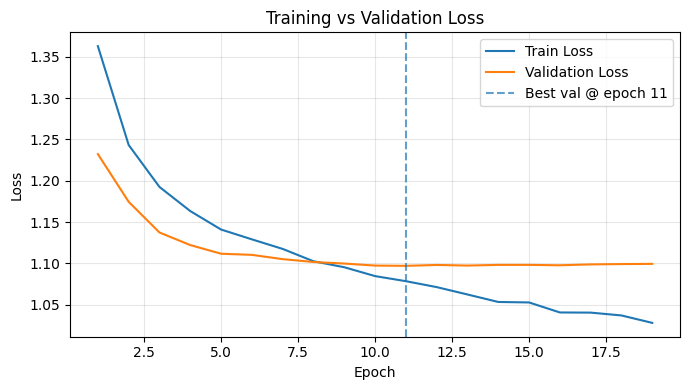

In [12]:
epochs = np.arange(1, len(tr_losses) + 1)
best_epoch = int(np.argmin(va_losses)) + 1  # epoch where val loss is minimal

plt.figure(figsize=(7, 4))
plt.plot(epochs, tr_losses, label="Train Loss")
plt.plot(epochs, va_losses, label="Validation Loss")
plt.axvline(best_epoch, linestyle="--", alpha=0.7, label=f"Best val @ epoch {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Model: Embeddings + Logistic reg

In [16]:
# -------- 1) Features, labels, groups
X = np.vstack(df_join['embedding'].apply(lambda v: np.array(v, dtype=np.float32)).values)

label_map = {'Positive':0, 'Neutral':1, 'Irrelevant':2, 'Negative':3}
inv_label_map = {v:k for k,v in label_map.items()}
y = df_join['sentiment'].map(label_map).values
groups_row = df_join['id'].values  # row-level group for masking later

# group-level labels for stratification
group_df = df_join[['id','sentiment']].drop_duplicates('id')
group_ids = group_df['id'].values
y_groups  = group_df['sentiment'].map(label_map).values

RANDOM_STATE = 10

# -------- 2) Outer split: single, clean, group-stratified holdout
outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
gtrain_idx, gtest_idx = next(outer.split(group_ids, y_groups, groups=group_ids))

train_group_ids = set(group_ids[gtrain_idx])
test_group_ids  = set(group_ids[gtest_idx])

train_mask = np.array([gid in train_group_ids for gid in groups_row])
test_mask  = np.array([gid in test_group_ids  for gid in groups_row])

# Leakage check
assert not set(groups_row[train_mask]).intersection(set(groups_row[test_mask])), \
       "Group leakage detected!"

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
groups_train = groups_row[train_mask]  # row-level groups for CV

# -------- 3) Model pipeline
pipe_lr = Pipeline([
    ('norm', Normalizer(norm='l2')),
    ('clf', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        C=1.0,
        solver='saga',
        n_jobs=-1
    ))
])

# -------- 4) CV on TRAINING GROUPS ONLY (inner CV)
inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_acc, cv_f1 = [], []
fold = 0
for tr_idx, val_idx in inner.split(X_train, y_train, groups=groups_train):
    fold += 1
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]
    # Optional: leakage sanity per fold
    assert not set(groups_train[tr_idx]).intersection(set(groups_train[val_idx]))

    pipe_lr.fit(X_tr, y_tr)
    y_val_pred = pipe_lr.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    f1m = f1_score(y_val, y_val_pred, average='macro')
    cv_acc.append(acc); cv_f1.append(f1m)
    print(f"[CV Fold {fold}] Acc={acc:.4f} | Macro-F1={f1m:.4f}")

print(f"\n[CV Summary on TRAIN] Acc: mean={np.mean(cv_acc):.4f} +/- {np.std(cv_acc):.4f} | "
      f"Macro-F1: mean={np.mean(cv_f1):.4f} +/- {np.std(cv_f1):.4f}")

# -------- 5) Final fit on FULL TRAIN, evaluate on HOLDOUT TEST
pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_test)

print("\n[Holdout (group-stratified, leakage-safe)]")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f} | Macro-F1: {f1_score(y_test, y_pred, average='macro'):.4f}\n")

print("Classification report:")
print(classification_report(y_test, y_pred, target_names=[inv_label_map[i] for i in range(4)]))

print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test, y_pred))

[CV Fold 1] Acc=0.5419 | Macro-F1=0.5274
[CV Fold 2] Acc=0.5420 | Macro-F1=0.5269
[CV Fold 3] Acc=0.5622 | Macro-F1=0.5474
[CV Fold 4] Acc=0.5332 | Macro-F1=0.5236
[CV Fold 5] Acc=0.5698 | Macro-F1=0.5592

[CV Summary on TRAIN] Acc: mean=0.5498 +/- 0.0138 | Macro-F1: mean=0.5369 +/- 0.0140

[Holdout (group-stratified, leakage-safe)]
Accuracy: 0.5673 | Macro-F1: 0.5538

Classification report:
              precision    recall  f1-score   support

    Positive       0.60      0.58      0.59      3824
     Neutral       0.56      0.51      0.53      3526
  Irrelevant       0.40      0.46      0.43      2575
    Negative       0.66      0.67      0.66      4225

    accuracy                           0.57     14150
   macro avg       0.55      0.55      0.55     14150
weighted avg       0.57      0.57      0.57     14150

Confusion matrix (rows=true, cols=pred):
[[2213  534  636  441]
 [ 571 1800  564  591]
 [ 515  431 1178  451]
 [ 380  455  554 2836]]
